# Treniranje modela za višeklasnu analizu sentimenta

Ovaj notebook učitava podatke pripremljene u `01data_preparation.ipynb`, trenira početni model i evaluira ga na validacionom skupu. Test skup ostaje netaknut do konačnog izbora modela.

In [25]:
import sys

print("Python verzija:", sys.version)
print("Python executable:", sys.executable)

Python verzija: 3.8.10 (default, Mar 18 2025, 20:04:55) 
[GCC 9.4.0]
Python executable: /usr/bin/python3


## Uvoz potrebnih biblioteka

In [ ]:
import pickle

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  accuracy_score,
  classification_report,
  f1_score,
  )
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

## Učitavanje pripremljenih podataka

Pickle sadrži TF-IDF matrice, ciljne oznake i vektorizator naučen isključivo na trening skupu.

In [27]:
with open("prepared_data.pkl", "rb") as f:
  (
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    vectorizer,
  ) = pickle.load(f)

validation_texts = pd.read_csv("data/validation_df.csv")["Text"]

In [28]:
assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val) == len(validation_texts)
assert X_test.shape[0] == len(y_test)
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert X_train.shape[1] == len(vectorizer.get_feature_names_out())

summary = pd.DataFrame({
  "skup": ["train", "validation", "test"],
  "broj_primera": [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
  "broj_atributa": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})
display(summary)

for name, labels in [("train", y_train), ("validation", y_val), ("test", y_test)]:
  print(f"\nRaspodela klasa - {name}:")
  print(labels.value_counts().sort_index())

,skup,broj_primera,broj_atributa
0,train,36000,10000
1,validation,7500,10000
2,test,7500,10000



Raspodela klasa - train:
Score
bad        12000
good       12000
neutral    12000
Name: count, dtype: int64

Raspodela klasa - validation:
Score
bad         847
good       5965
neutral     688
Name: count, dtype: int64

Raspodela klasa - test:
Score
bad         850
good       5937
neutral     713
Name: count, dtype: int64


## Baseline: multinomijalna logistička regresija

Model se trenira samo na trening skupu. Validacioni skup koristimo za početnu procenu kvaliteta i kasnije poređenje modela.

In [29]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

In [30]:
print(f"Validation accuracy:    {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Validation macro F1:    {f1_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Validation weighted F1: {f1_score(y_val, y_val_pred, average='weighted'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_val, y_val_pred, digits=4))

Validation accuracy:    0.8284
Validation macro F1:    0.7121
Validation weighted F1: 0.8467

Classification report:

              precision    recall  f1-score   support

         bad     0.6524    0.8111    0.7232       847
        good     0.9740    0.8417    0.9031      5965
     neutral     0.3909    0.7340    0.5101       688

    accuracy                         0.8284      7500
   macro avg     0.6724    0.7956    0.7121      7500
weighted avg     0.8842    0.8284    0.8467      7500



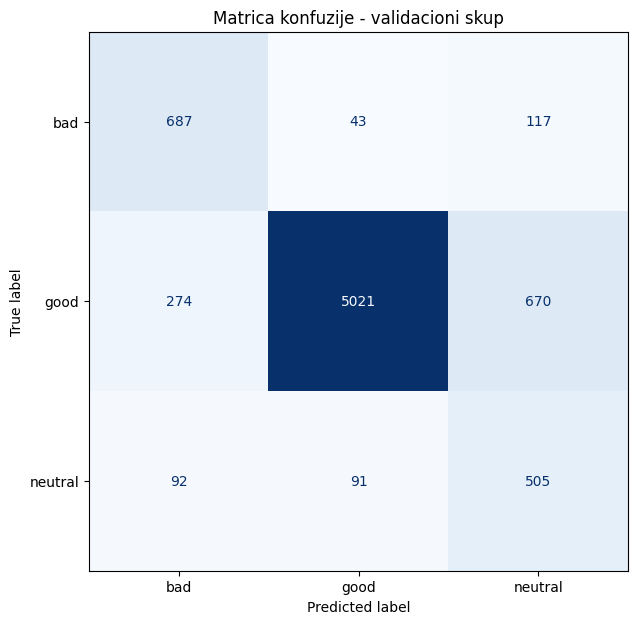

In [31]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_val,
  y_val_pred,
  cmap="Blues",
  ax=ax,
  colorbar=False,
  )
ax.set_title("Matrica konfuzije - validacioni skup")
plt.show()

## LinearSVC i podešavanje parametra `C`

`LinearSVC` traži linearnu granicu između klasa i dobro radi sa retkim TF-IDF matricama. Parametar `C` kontroliše jačinu regularizacije: manji `C` znači jaču regularizaciju. Najbolju vrednost biramo prema macro F1 na validacionom skupu.

In [32]:
c_values = [0.01, 0.03, 0.1, 0.3, 1.0]
svc_results = []
svc_models = {}

for c_value in c_values:
  candidate = LinearSVC(
    C=c_value,
    dual=True,
    max_iter=5000,
    random_state=42,
  )
  candidate.fit(X_train, y_train)
  candidate_pred = candidate.predict(X_val)

  svc_models[c_value] = candidate
  svc_results.append({
    "C": c_value,
    "accuracy": accuracy_score(y_val, candidate_pred),
    "macro_f1": f1_score(y_val, candidate_pred, average="macro"),
    "weighted_f1": f1_score(y_val, candidate_pred, average="weighted"),
  })

svc_results_df = pd.DataFrame(svc_results)
display(svc_results_df.round(4))

best_c = svc_results_df.loc[svc_results_df["macro_f1"].idxmax(), "C"]
best_svc = svc_models[best_c]
y_val_pred_svc = best_svc.predict(X_val)

print(f"Najbolji C prema validation macro F1: {best_c}")

,C,accuracy,macro_f1,weighted_f1
0,0.01,0.8071,0.6732,0.8272
1,0.03,0.8215,0.6948,0.8398
2,0.10,0.8332,0.7124,0.8497
3,0.30,0.8341,0.7154,0.8508
4,1.00,0.8232,0.7013,0.8420


Najbolji C prema validation macro F1: 0.3


In [33]:
print(f"LinearSVC validation accuracy:    {accuracy_score(y_val, y_val_pred_svc):.4f}")
print(f"LinearSVC validation macro F1:    {f1_score(y_val, y_val_pred_svc, average='macro'):.4f}")
print(f"LinearSVC validation weighted F1: {f1_score(y_val, y_val_pred_svc, average='weighted'):.4f}")
print("\nClassification report:\n")
print(classification_report(y_val, y_val_pred_svc, digits=4))

LinearSVC validation accuracy:    0.8341
LinearSVC validation macro F1:    0.7154
LinearSVC validation weighted F1: 0.8508

Classification report:

              precision    recall  f1-score   support

         bad     0.6537    0.8135    0.7249       847
        good     0.9726    0.8508    0.9076      5965
     neutral     0.4007    0.7151    0.5136       688

    accuracy                         0.8341      7500
   macro avg     0.6756    0.7931    0.7154      7500
weighted avg     0.8841    0.8341    0.8508      7500



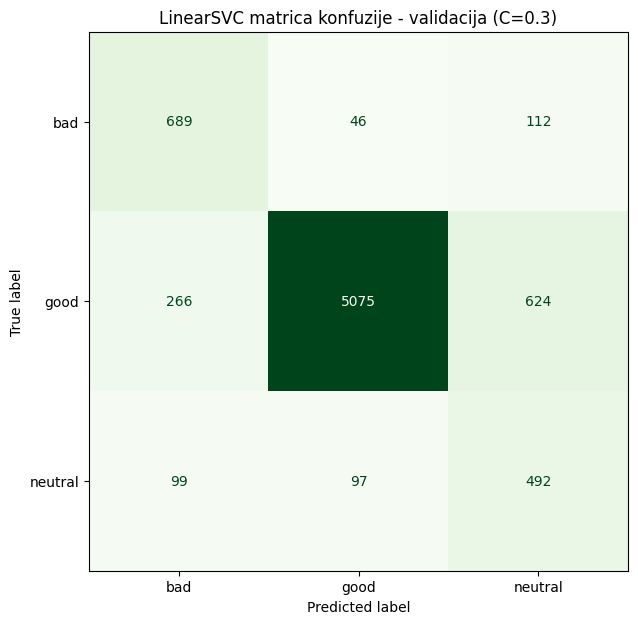

In [34]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_val,
  y_val_pred_svc,
  cmap="Greens",
  ax=ax,
  colorbar=False,
  )
ax.set_title(f"LinearSVC matrica konfuzije - validacija (C={best_c:g})")
plt.show()

## Dodatni kandidat

Pored logističke regresije i `LinearSVC`, proveravamo `ComplementNB`, koji je prilagođen nenegativnim i retkim TF-IDF atributima.

In [35]:
nb_results = []
nb_models = {}

for alpha in [0.1, 0.5, 1.0, 2.0, 5.0]:
  candidate = ComplementNB(alpha=alpha)
  candidate.fit(X_train, y_train)
  candidate_pred = candidate.predict(X_val)

  nb_models[alpha] = candidate
  nb_results.append({
    "alpha": alpha,
    "accuracy": accuracy_score(y_val, candidate_pred),
    "macro_f1": f1_score(y_val, candidate_pred, average="macro"),
    "weighted_f1": f1_score(y_val, candidate_pred, average="weighted"),
  })

nb_results_df = pd.DataFrame(nb_results)
display(nb_results_df.round(4))

best_alpha = nb_results_df.loc[nb_results_df["macro_f1"].idxmax(), "alpha"]
best_nb = nb_models[best_alpha]
y_val_pred_nb = best_nb.predict(X_val)
print(f"Najbolji alpha prema validation macro F1: {best_alpha}")

,alpha,accuracy,macro_f1,weighted_f1
0,0.1,0.8123,0.6753,0.8297
1,0.5,0.8155,0.6788,0.8324
2,1.0,0.8163,0.6793,0.8329
3,2.0,0.8196,0.6836,0.8359
4,5.0,0.8197,0.6862,0.8366


Najbolji alpha prema validation macro F1: 5.0


## Poređenje i analiza validacionih grešaka

In [38]:
validation_predictions = {
  "LogisticRegression": y_val_pred,
  "LinearSVC": y_val_pred_svc,
  "ComplementNB": y_val_pred_nb,
}

comparison_rows = []
for model_name, predictions in validation_predictions.items():
  comparison_rows.append({
    "model": model_name,
    "accuracy": accuracy_score(y_val, predictions),
    "macro_f1": f1_score(y_val, predictions, average="macro"),
    "weighted_f1": f1_score(y_val, predictions, average="weighted"),
  })

comparison_df = (
  pd.DataFrame(comparison_rows)
  .sort_values("macro_f1", ascending=False)
  .reset_index(drop=True)
  )
display(comparison_df.round(4))

best_model_name = comparison_df.loc[0, "model"]
best_validation_pred = validation_predictions[best_model_name]
print(f"Izabrani model prema validation macro F1: {best_model_name}")

,model,accuracy,macro_f1,weighted_f1
0,LinearSVC,0.8341,0.7154,0.8508
1,LogisticRegression,0.8284,0.7121,0.8467
2,ComplementNB,0.8197,0.6862,0.8366


Izabrani model prema validation macro F1: LinearSVC


In [ ]:
validation_analysis = pd.DataFrame({
  "text": validation_texts.astype(str),
  "actual": np.asarray(y_val),
  "predicted": best_validation_pred,
})
validation_analysis["is_misclassified"] = (
  validation_analysis["actual"] != validation_analysis["predicted"]
  )

confusion_pairs = (
  validation_analysis.loc[validation_analysis["is_misclassified"]]
  .groupby(["actual", "predicted"])
  .size()
  .sort_values(ascending=False)
  .rename("count")
  .reset_index()
  )
display(confusion_pairs.head(10))

misclassified_examples = (
  validation_analysis.loc[validation_analysis["is_misclassified"]]
  .head(10)
  .copy()
  )
misclassified_examples["text"] = misclassified_examples["text"].str.slice(0, 300)
display(misclassified_examples)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

## Završna procena na test skupu

Nakon izbora modela isključivo prema validacionom macro F1 rezultatu, test skup koristimo jednom za završnu nepristrasnu procenu.

Konačni model: LinearSVC
Test accuracy: 0.6317
Test macro_f1: 0.4627
Test weighted_f1: 0.6517
Test mae: 0.6197

Test classification report:

              precision    recall  f1-score   support

           1     0.4650    0.6848    0.5539       660
           2     0.2387    0.3144    0.2713       369
           3     0.2945    0.3603    0.3241       569
           4     0.3341    0.4068    0.3669      1089
           5     0.8761    0.7318    0.7975      4813

    accuracy                         0.6317      7500
   macro avg     0.4417    0.4996    0.4627      7500
weighted avg     0.6858    0.6317    0.6517      7500



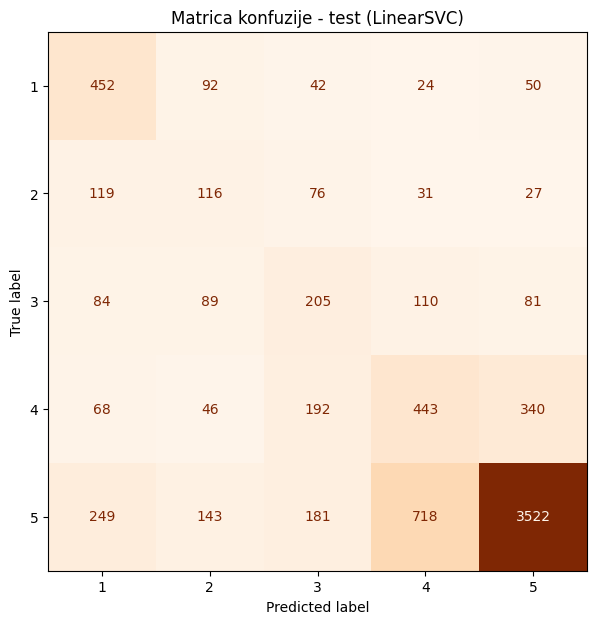

In [ ]:
if best_model_name == "LogisticRegression":
  final_model = model
elif best_model_name == "LinearSVC":
  final_model = best_svc
else:
  final_model = best_nb

y_test_pred = final_model.predict(X_test)

test_metrics = {
  "accuracy": accuracy_score(y_test, y_test_pred),
  "macro_f1": f1_score(y_test, y_test_pred, average="macro"),
  "weighted_f1": f1_score(y_test, y_test_pred, average="weighted"),
}

print(f"Konačni model: {best_model_name}")
for metric_name, metric_value in test_metrics.items():
  print(f"Test {metric_name}: {metric_value:.4f}")
print("\nTest classification report:\n")
print(classification_report(y_test, y_test_pred, digits=4))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
  y_test,
  y_test_pred,
  cmap="Oranges",
  ax=ax,
  colorbar=False,
  )
ax.set_title(f"Matrica konfuzije - test ({best_model_name})")
plt.show()

In [22]:
model_artifact = {
  "model_name": best_model_name,
  "model": final_model,
  "vectorizer": vectorizer,
  "validation_results": comparison_df,
  "test_metrics": test_metrics,
  "classes": np.sort(np.asarray(y_train.unique())),
  "feature_count": X_train.shape[1],
}

joblib.dump(model_artifact, "sentiment_model.joblib")
print("Model je sačuvan u sentiment_model.joblib")

Model je sačuvan u sentiment_model.joblib


## Predikcija novih recenzija

Sačuvani artefakt sadrži i vektorizator i model, pa se nova recenzija obrađuje potpuno istim postupkom kao podaci za treniranje.

In [ ]:
import re

import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

loaded_artifact = joblib.load("sentiment_model.joblib")
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
  tag = nltk.pos_tag([word])[0][1].upper()
  if tag.startswith("J") or tag.startswith("S"):
    return wordnet.ADJ
  if tag.startswith("V"):
    return wordnet.VERB
  if tag.startswith("N"):
    return wordnet.NOUN
  if tag.startswith("R"):
    return wordnet.ADV
  return wordnet.NOUN

def lemmatize_text(text):
  if not isinstance(text, str):
    return ""

  text = text.lower()
  text = re.sub(r"<.*?>", " ", text)
  text = re.sub(r"[^a-zA-Z\s]", " ", text)
  words = text.split()

  lemmatized_words = [
    lemmatizer.lemmatize(word, pos=get_wordnet_pos(word))
    for word in words
  ]
  return " ".join(lemmatized_words)

def predict_reviews(texts):
  cleaned_texts = [lemmatize_text(text) for text in texts]
  text_features = loaded_artifact["vectorizer"].transform(cleaned_texts)
  predictions = loaded_artifact["model"].predict(text_features)

  return pd.DataFrame({
    "text": texts,
    "predicted_sentiment": predictions,
  })

In [24]:
example_reviews = [
  "Absolutely delicious, fresh, and worth every penny.",
  "It is acceptable, but nothing special and a little overpriced.",
  "The package arrived damaged and the product tasted awful.",
]

display(predict_reviews(example_reviews))

,text,predicted_score
0,"Absolutely delicious, fresh, and worth every p...",5
1,"It is acceptable, but nothing special and a li...",3
2,The package arrived damaged and the product ta...,1
